# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Kadek Aditya Gimas Tangkas Kori Agung
- **Email:** agung.2305551081@student.unud.ac.id
- **ID Dicoding:** adityagimas

## Menentukan Pertanyaan Bisnis

**Pertanyaan Bisnis:**
- Bagaimana pertumbuhan rata-rata dan total penyewaan sepeda antara tahun 2011 dan 2012?
- Pada musim apa rata-rata jumlah penyewaan paling tinggi selama periode 2011–2012?
- Pada jam berapa rata-rata penyewaan sepeda tertinggi terjadi dalam dua tahun terakhir?
- Bagaimana perbedaan pola penyewaan per jam antara hari kerja dan akhir pekan?
- Seberapa besar hubungan antara suhu, kelembapan, dan kecepatan angin terhadap jumlah penyewaan harian selama 2011–2012?
- Berapa perbedaan rata-rata jumlah penyewaan antara hari kerja dan hari libur?
- Bagaimana kontribusi pengguna kasual dan terdaftar terhadap total penyewaan selama 2 tahun terakhir?

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

## Data Wrangling

### Gathering Data

In [2]:
day_df = pd.read_csv("data/day.csv")

day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [3]:
hour_df = pd.read_csv("data/hour.csv")

hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Berdasarkan tahap data gathering dan preview lima baris pertama dari kedua dataset, terlihat bahwa data terdiri dari dua tingkat agregasi yaitu harian (day_df) dan per jam (hour_df), di mana dataset per jam memiliki kolom tambahan hr untuk menunjukkan waktu spesifik penyewaan.
- Kedua dataset telah menyediakan variabel waktu yang lengkap seperti dteday, yr, mnth, weekday, workingday, dan holiday, serta variabel cuaca dan lingkungan seperti season, weathersit, temp, atemp, hum, dan windspeed. Variabel target utama adalah cnt, yang merupakan penjumlahan dari casual dan registered, sehingga memungkinkan analisis segmentasi pengguna.

### Assessing Data

day_df

In [4]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [5]:
day_df.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [6]:
day_df.duplicated().sum()

np.int64(0)

In [7]:
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Insight:**
- Tabel day_df, dataset terdiri dari 731 observasi dengan 15 kolom dan tidak ditemukan missing value maupun data duplikat, sehingga secara umum kualitas data sudah baik.
- Kolom dteday masih bertipe object dan perlu dikonversi ke tipe datetime untuk analisis berbasis waktu. Variabel seperti season, yr, mnth, holiday, weekday, workingday, dan weathersit merupakan variabel kategorikal yang masih direpresentasikan dalam bentuk numerik sehingga memerlukan transformasi label agar lebih interpretatif.
- Dari hasil statistik deskriptif terlihat bahwa rata-rata total penyewaan sepeda (cnt) adalah sekitar 4.504 unit per hari dengan nilai minimum 22 dan maksimum 8.714, menunjukkan variasi permintaan yang cukup besar antar hari. Kuartil pertama (Q1) sebesar 3.152 dan kuartil ketiga (Q3) sebesar 5.956 mengindikasikan distribusi data yang cukup lebar, sehingga terdapat kemungkinan perbedaan signifikan antara hari dengan permintaan rendah dan tinggi.
- Rata-rata pengguna terdaftar (registered) sebesar 3.656 jauh lebih tinggi dibandingkan pengguna casual (848), yang menunjukkan bahwa sebagian besar penyewaan berasal dari pelanggan terdaftar.
- Untuk variabel lingkungan seperti temp, atemp, hum, dan windspeed, nilainya berada pada rentang 0–1 karena telah dinormalisasi, dengan rata-rata suhu ternormalisasi sekitar 0.495 dan kelembapan sekitar 0.628.

hour_df

In [8]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [9]:
hour_df.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [10]:
hour_df.duplicated().sum()

np.int64(0)

In [11]:
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Insight:**
- Berdasarkan proses assessing data pada hour_df, dataset terdiri dari 17.379 observasi dengan 16 kolom dan tidak ditemukan missing value maupun data duplikat, sehingga kualitas data secara umum sangat baik.
- Dataset ini memiliki struktur yang serupa dengan day_df, namun ditambahkan kolom hr yang merepresentasikan jam (0–23), sehingga memungkinkan analisis pola permintaan secara lebih detail dalam satu hari.
- Dari statistik deskriptif terlihat bahwa rata-rata total penyewaan sepeda (cnt) adalah sekitar 189 unit per jam, dengan nilai minimum 1 dan maksimum 977, menunjukkan variasi permintaan yang cukup signifikan antar jam. Kuartil pertama (Q1) sebesar 40 dan kuartil ketiga (Q3) sebesar 281 mengindikasikan distribusi yang cukup lebar, sehingga terdapat perbedaan yang jelas antara jam dengan permintaan rendah dan jam sibuk.
- Rata-rata pengguna terdaftar (registered) sebesar 153 per jam jauh lebih tinggi dibandingkan pengguna casual (35 per jam), yang menunjukkan bahwa sebagian besar penyewaan per jam didominasi oleh pengguna terdaftar.
- Variabel lingkungan seperti temp, atemp, hum, dan windspeed berada pada rentang 0–1 karena telah dinormalisasi, dengan rata-rata suhu ternormalisasi sekitar 0.497 dan kelembapan sekitar 0.627.

### Cleaning Data

Ubah Tipe Data dteday ke Datetime

In [12]:
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

Mapping Variabel Kategorikal

In [13]:
# Mapping season
season_map = {
    1: 'Winter',
    2: 'Spring',
    3: 'Summer',
    4: 'Fall'
}

# Mapping weather
weather_map = {
    1: 'Clear',
    2: 'Mist/Cloudy',
    3: 'Light Rain/Snow',
    4: 'Heavy Rain/Snow'
}

# Mapping tahun
year_map = {
    0: 2011,
    1: 2012
}

day_df['season'] = day_df['season'].map(season_map)
hour_df['season'] = hour_df['season'].map(season_map)

day_df['weathersit'] = day_df['weathersit'].map(weather_map)
hour_df['weathersit'] = hour_df['weathersit'].map(weather_map)

day_df['year'] = day_df['yr'].map(year_map)
hour_df['year'] = hour_df['yr'].map(year_map)

Menambahkan Nama Bulan

In [14]:
day_df['month_name'] = day_df['dteday'].dt.month_name()
hour_df['month_name'] = hour_df['dteday'].dt.month_name()

Menambahkan Nama Weekday

In [15]:
day_df['weekday_name'] = day_df['dteday'].dt.day_name()
hour_df['weekday_name'] = hour_df['dteday'].dt.day_name()

Tambahkan Label Working Day

In [16]:
day_df['day_type'] = day_df['workingday'].map({1: 'Working Day', 0: 'Holiday/Weekend'})
hour_df['day_type'] = hour_df['workingday'].map({1: 'Working Day', 0: 'Holiday/Weekend'})

Konversi Suhu ke Celsius

In [17]:
day_df['temp_celsius'] = day_df['temp'] * 41
hour_df['temp_celsius'] = hour_df['temp'] * 41

Drop Kolom yang Tidak Diperlukan

In [18]:
day_df.drop('instant', axis=1, inplace=True)
hour_df.drop('instant', axis=1, inplace=True)

day_df setelah cleaning

In [19]:
day_df

,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,year,month_name,weekday_name,day_type,temp_celsius
0,2011-01-01,Winter,0,1,0,6,0,Mist/Cloudy,0.344167,0.363625,0.805833,0.160446,331,654,985,2011,January,Saturday,Holiday/Weekend,14.110847
1,2011-01-02,Winter,0,1,0,0,0,Mist/Cloudy,0.363478,0.353739,0.696087,0.248539,131,670,801,2011,January,Sunday,Holiday/Weekend,14.902598
2,2011-01-03,Winter,0,1,0,1,1,Clear,0.196364,0.189405,0.437273,0.248309,120,1229,1349,2011,January,Monday,Working Day,8.050924
3,2011-01-04,Winter,0,1,0,2,1,Clear,0.200000,0.212122,0.590435,0.160296,108,1454,1562,2011,January,Tuesday,Working Day,8.200000
4,2011-01-05,Winter,0,1,0,3,1,Clear,0.226957,0.229270,0.436957,0.186900,82,1518,1600,2011,January,Wednesday,Working Day,9.305237
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,2012-12-27,Winter,1,12,0,4,1,Mist/Cloudy,0.254167,0.226642,0.652917,0.350133,247,1867,2114,2012,December,Thursday,Working Day,10.420847
727,2012-12-28,Winter,1,12,0,5,1,Mist/Cloudy,0.253333,0.255046,0.590000,0.155471,644,2451,3095,2012,December,Friday,Working Day,10.386653
728,2012-12-29,Winter,1,12,0,6,0,Mist/Cloudy,0.253333,0.242400,0.752917,0.124383,159,1182,1341,2012,December,Saturday,Holiday/Weekend,10.386653
729,2012-12-30,Winter,1,12,0,0,0,Clear,0.255833,0.231700,0.483333,0.350754,364,1432,1796,2012,December,Sunday,Holiday/Weekend,10.489153


hour_df setelah cleaning

In [20]:
hour_df

,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,...,hum,windspeed,casual,registered,cnt,year,month_name,weekday_name,day_type,temp_celsius
0,2011-01-01,Winter,0,1,0,0,6,0,Clear,0.24,...,0.81,0.0000,3,13,16,2011,January,Saturday,Holiday/Weekend,9.84
1,2011-01-01,Winter,0,1,1,0,6,0,Clear,0.22,...,0.80,0.0000,8,32,40,2011,January,Saturday,Holiday/Weekend,9.02
2,2011-01-01,Winter,0,1,2,0,6,0,Clear,0.22,...,0.80,0.0000,5,27,32,2011,January,Saturday,Holiday/Weekend,9.02
3,2011-01-01,Winter,0,1,3,0,6,0,Clear,0.24,...,0.75,0.0000,3,10,13,2011,January,Saturday,Holiday/Weekend,9.84
4,2011-01-01,Winter,0,1,4,0,6,0,Clear,0.24,...,0.75,0.0000,0,1,1,2011,January,Saturday,Holiday/Weekend,9.84
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,2012-12-31,Winter,1,12,19,0,1,1,Mist/Cloudy,0.26,...,0.60,0.1642,11,108,119,2012,December,Monday,Working Day,10.66
17375,2012-12-31,Winter,1,12,20,0,1,1,Mist/Cloudy,0.26,...,0.60,0.1642,8,81,89,2012,December,Monday,Working Day,10.66
17376,2012-12-31,Winter,1,12,21,0,1,1,Clear,0.26,...,0.60,0.1642,7,83,90,2012,December,Monday,Working Day,10.66
17377,2012-12-31,Winter,1,12,22,0,1,1,Clear,0.26,...,0.56,0.1343,13,48,61,2012,December,Monday,Working Day,10.66


**Insight:**
- Kolom dteday dikonversi ke tipe datetime untuk mendukung analisis berbasis waktu seperti analisis bulanan dan harian.
- Variabel season dan weathersit dipetakan dari bentuk numerik ke label deskriptif (Winter, Spring, Summer, Fall serta Clear, Mist/Cloudy, dll.) agar lebih mudah diinterpretasikan.
- Variabel yr dikonversi menjadi kolom baru year dengan nilai 2011 dan 2012 untuk mempermudah analisis per tahun.
- Ditambahkan kolom month_name dan weekday_name berdasarkan dteday untuk memperkaya analisis pola musiman dan pola harian.
- Dibuat kolom day_type untuk membedakan antara Working Day dan Holiday/Weekend guna menganalisis perbedaan pola penyewaan berdasarkan jenis hari.
- Variabel suhu yang sebelumnya dalam bentuk ternormalisasi dikonversi ke skala Celsius (temp_celsius) agar lebih intuitif dalam interpretasi.
- Kolom instant dihapus karena hanya berfungsi sebagai indeks dan tidak memiliki nilai analitis.

## Exploratory Data Analysis (EDA)

### Statistik Deskriptif Umum

In [21]:
day_df.describe(include='all')

,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,year,month_name,weekday_name,day_type,temp_celsius
count,731,731,731.000000,731.000000,731.000000,731.000000,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731,731,731,731.000000
unique,NaN,4,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12,7,2,NaN
top,NaN,Summer,NaN,NaN,NaN,NaN,NaN,Clear,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,January,Saturday,Working Day,NaN
freq,NaN,188,NaN,NaN,NaN,NaN,NaN,463,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,62,105,500,NaN
mean,2012-01-01 00:00:00,NaN,0.500684,6.519836,0.028728,2.997264,0.683995,NaN,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837,2011.500684,NaN,NaN,NaN,20.310776
min,2011-01-01 00:00:00,NaN,0.000000,1.000000,0.000000,0.000000,0.000000,NaN,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000,2011.000000,NaN,NaN,NaN,2.424346
25%,2011-07-02 12:00:00,NaN,0.000000,4.000000,0.000000,1.000000,0.000000,NaN,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000,2011.000000,NaN,NaN,NaN,13.820424
50%,2012-01-01 00:00:00,NaN,1.000000,7.000000,0.000000,3.000000,1.000000,NaN,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000,2012.000000,NaN,NaN,NaN,20.431653
75%,2012-07-01 12:00:00,NaN,1.000000,10.000000,0.000000,5.000000,1.000000,NaN,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000,2012.000000,NaN,NaN,NaN,26.872076
max,2012-12-31 00:00:00,NaN,1.000000,12.000000,1.000000,6.000000,1.000000,NaN,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000,2012.000000,NaN,NaN,NaN,35.328347


**Insight:**
- Dataset harian terdiri dari 731 data dengan rata-rata penyewaan sepeda per hari sekitar 4.500 unit, dengan rentang yang sangat lebar (22 hingga 8.714), menunjukkan fluktuasi permintaan yang signifikan antar hari. Pengguna registered jauh lebih mendominasi dibandingkan casual, yang mengindikasikan bahwa layanan ini lebih banyak digunakan oleh pelanggan tetap.
- Variasi yang cukup besar pada standar deviasi menunjukkan bahwa permintaan dipengaruhi oleh faktor eksternal seperti musim dan cuaca. Kondisi cuaca “Clear” dan hari kerja menjadi kategori yang paling sering muncul, yang kemungkinan berkontribusi terhadap tingginya rata-rata penyewaan.

In [22]:
hour_df.describe(include='all')

,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,...,hum,windspeed,casual,registered,cnt,year,month_name,weekday_name,day_type,temp_celsius
count,17379,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379,17379.000000,...,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379,17379,17379,17379.000000
unique,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,12,7,2,NaN
top,NaN,Summer,NaN,NaN,NaN,NaN,NaN,NaN,Clear,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,July,Saturday,Working Day,NaN
freq,NaN,4496,NaN,NaN,NaN,NaN,NaN,NaN,11413,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1488,2512,11865,NaN
mean,2012-01-02 04:08:34.552045568,NaN,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,NaN,0.496987,...,0.627229,0.190098,35.676218,153.786869,189.463088,2011.502561,NaN,NaN,NaN,20.376474
min,2011-01-01 00:00:00,NaN,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.020000,...,0.000000,0.000000,0.000000,0.000000,1.000000,2011.000000,NaN,NaN,NaN,0.820000
25%,2011-07-04 00:00:00,NaN,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,NaN,0.340000,...,0.480000,0.104500,4.000000,34.000000,40.000000,2011.000000,NaN,NaN,NaN,13.940000
50%,2012-01-02 00:00:00,NaN,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,NaN,0.500000,...,0.630000,0.194000,17.000000,115.000000,142.000000,2012.000000,NaN,NaN,NaN,20.500000
75%,2012-07-02 00:00:00,NaN,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,NaN,0.660000,...,0.780000,0.253700,48.000000,220.000000,281.000000,2012.000000,NaN,NaN,NaN,27.060000
max,2012-12-31 00:00:00,NaN,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,NaN,1.000000,...,1.000000,0.850700,367.000000,886.000000,977.000000,2012.000000,NaN,NaN,NaN,41.000000


**Insight:**
- Dataset per jam terdiri dari 17.379 observasi dengan rata-rata penyewaan sekitar 189 unit per jam. Rentang yang besar (hingga 977 unit per jam) menunjukkan adanya pola peak dan off-peak hours yang cukup jelas. Pengguna registered kembali mendominasi dibandingkan casual, menandakan pola penggunaan yang lebih rutin.
- Standar deviasi yang relatif tinggi mengindikasikan variasi permintaan yang kuat antar jam, yang kemungkinan berkaitan dengan jam sibuk (commuting hours). Mayoritas data terjadi pada kondisi cuaca cerah dan hari kerja.

### Penggunaan Sepeda

In [23]:
yearly_summary = day_df.groupby('year')['cnt'].agg(
    total_rental='sum',
    average_rental='mean'
)

yearly_summary

,total_rental,average_rental
year,,
2011,1243103,3405.761644
2012,2049576,5599.934426


**Insight:**
- Berdasarkan hasil agregasi tahunan, total penyewaan sepeda meningkat signifikan dari 1.243.103 unit pada tahun 2011 menjadi 2.049.576 unit pada tahun 2012. Secara rata-rata harian, jumlah penyewaan juga mengalami kenaikan dari sekitar 3.406 unit per hari pada 2011 menjadi 5.600 unit per hari pada 2012. Hal ini menunjukkan adanya peningkatan permintaan yang konsisten sepanjang tahun kedua operasional.

In [24]:
yearly_summary['growth_%'] = yearly_summary['total_rental'].pct_change() * 100
yearly_summary

,total_rental,average_rental,growth_%
year,,,
2011,1243103,3405.761644,NaN
2012,2049576,5599.934426,64.875799


**Insight:**
- Persentase pertumbuhan total penyewaan mencapai sekitar 64,88%, yang mengindikasikan ekspansi penggunaan layanan yang sangat kuat dalam satu tahun. Kenaikan yang besar ini dapat mencerminkan peningkatan adopsi layanan oleh masyarakat, pertumbuhan jumlah pengguna terdaftar, atau peningkatan efektivitas sistem operasional.

In [25]:
month = (
    day_df
    .groupby(['year', 'mnth'])['cnt']
    .mean()
    .unstack(level=0)
)

month

year,2011,2012
mnth,,
1,1231.903226,3120.774194
2,1721.964286,3556.448276
3,2065.967742,5318.548387
4,3162.333333,5807.466667
5,4381.322581,6318.225806
6,4783.733333,6761.000000
7,4559.387097,6567.967742
8,4409.387097,6919.451613
9,4247.266667,7285.766667


**Insight:**
- Dari tabel rata-rata penyewaan per bulan antara 2011 dan 2012, terlihat bahwa setiap bulan di tahun 2012 memiliki rata-rata rental yang jauh lebih tinggi dibandingkan 2011. Ini menunjukkan adanya pertumbuhan penggunaan yang konsisten dari tahun pertama ke tahun kedua.
- Pada tahun 2011, rata-rata penyewaan meningkat dari awal tahun dan mencapai puncak sekitar bulan Juni (4.783), kemudian menurun menjelang akhir tahun. Pola ini menunjukkan tren musiman yang cukup jelas.
- Sementara itu, pada 2012, rata-rata penyewaan tidak hanya lebih tinggi, tetapi juga mencapai puncak yang lebih besar, yaitu pada bulan September (7.285). Bahkan di bulan Januari saja (3.120), rata-rata 2012 sudah lebih tinggi dibanding beberapa bulan pertengahan 2011.

### Distribusi Musiman

In [26]:
season_summary = day_df.groupby('season')['cnt'].agg(
    total_rental='sum',
    average_rental='mean'
).sort_values(by='average_rental', ascending=False)

season_summary

,total_rental,average_rental
season,,
Summer,1061129,5644.303191
Spring,918589,4992.331522
Fall,841613,4728.162921
Winter,471348,2604.132597


**Insight:**
- Terlihat bahwa Summer memiliki jumlah penyewaan tertinggi dengan total 1.061.129 dan rata-rata sekitar 5.644 penyewaan per hari. Hal ini menunjukkan bahwa kondisi cuaca yang hangat dan lebih stabil sangat mendukung aktivitas bersepeda. Spring berada di posisi kedua dengan rata-rata sekitar 4.992 per hari, diikuti oleh Fall dengan 4.728 per hari, yang menunjukkan bahwa musim dengan suhu sedang tetap mempertahankan permintaan yang cukup tinggi.
- Sebaliknya, Winter mencatat angka terendah secara signifikan, dengan total 471.348 dan rata-rata hanya sekitar 2.604 penyewaan per hari. Penurunan drastis ini mengindikasikan bahwa suhu rendah dan kondisi cuaca yang kurang mendukung menjadi faktor utama berkurangnya penggunaan sepeda.

### Jam dan Jenis Hari

In [27]:
hourly_mean = hour_df.groupby('hr')['cnt'].mean().sort_values(ascending=False)
hourly_mean.head()

hr
17    461.452055
18    425.510989
8     359.011004
16    311.983562
19    311.523352
Name: cnt, dtype: float64

**Insight:**
- Rata-rata penyewaan tertinggi terjadi pada jam 17.00 (461) dan 18.00 (425), diikuti jam 08.00 (359). Pola ini menunjukkan adanya rush hour, yaitu lonjakan saat berangkat dan pulang kerja.

In [28]:
hour_daytype = hour_df.groupby(['day_type', 'hr'])['cnt'].mean().reset_index()
hour_daytype.sort_values(by='cnt', ascending=False).head(10)

,day_type,hr,cnt
41,Working Day,17,525.290581
42,Working Day,18,492.226908
32,Working Day,8,477.006048
13,Holiday/Weekend,13,372.731602
12,Holiday/Weekend,12,366.259740
14,Holiday/Weekend,14,364.645022
15,Holiday/Weekend,15,358.813853
16,Holiday/Weekend,16,352.727273
43,Working Day,19,348.401606
17,Holiday/Weekend,17,323.549784


**Insight:**
- Pada hari kerja, puncak tertinggi terjadi pada jam 17.00 (525) dan 18.00 (492), serta 08.00 (477). Ini jelas menunjukkan pola jam berangkat dan pulang kerja (rush hour) yang sangat kuat.
- Sebaliknya, pada Holiday/Weekend, penyewaan tertinggi terjadi di jam 12.00–16.00 (sekitar 352–372), yaitu waktu siang hingga sore, bukan pagi hari. Polanya lebih menyebar dan tidak setajam hari kerja.

In [29]:
daytype_mean = day_df.groupby('day_type')['cnt'].mean()
daytype_mean

day_type
Holiday/Weekend    4330.168831
Working Day        4584.820000
Name: cnt, dtype: float64

**Insight:**
- Rata-rata penyewaan pada Working Day (4.585) sedikit lebih tinggi dibandingkan Holiday/Weekend (4.330).Artinya, meskipun perbedaannya tidak terlalu besar, sepeda lebih banyak digunakan pada hari kerja. Ini memperkuat temuan sebelumnya bahwa layanan bike-sharing dalam dataset ini cenderung dimanfaatkan untuk aktivitas rutin, bukan murni rekreasi.

### Pengaruh Cuaca

In [30]:
weather_summary = (day_df.groupby('weathersit')['cnt'].agg(total_rental='sum', average_rental='mean')
    .sort_values(by='average_rental', ascending=False)
    .reset_index()
)

weather_summary

,weathersit,total_rental,average_rental
0,Clear,2257952,4876.786177
1,Mist/Cloudy,996858,4035.862348
2,Light Rain/Snow,37869,1803.285714


**Insight:**
- Kondisi Clear menghasilkan jumlah penyewaan tertinggi dengan total 2.257.952 dan rata-rata sekitar 4.877 penyewaan per hari. Ini menunjukkan bahwa cuaca cerah sangat mendukung aktivitas bersepeda dan mendorong tingginya permintaan.
- Pada kondisi Mist/Cloudy, total penyewaan menurun menjadi 996.858 dengan rata-rata sekitar 4.036 per hari, namun masih tergolong tinggi. Artinya, cuaca mendung atau berkabut ringan tidak terlalu menghambat penggunaan sepeda.
- Saat Light Rain/Snow, jumlah penyewaan turun drastis menjadi hanya 37.869 dengan rata-rata sekitar 1.803 per hari. Penurunan signifikan ini menunjukkan bahwa hujan atau salju ringan berdampak besar terhadap minat masyarakat untuk menggunakan sepeda.

In [31]:
weather_user = day_df.groupby('weathersit')[['casual', 'registered']].mean()

weather_user

,casual,registered
weathersit,,
Clear,964.030238,3912.755940
Light Rain/Snow,185.476190,1617.809524
Mist/Cloudy,687.352227,3348.510121


**Insight:**
- Berdasarkan rata-rata penyewaan per tipe pengguna dan kondisi cuaca, terlihat bahwa pada kondisi Clear, jumlah pengguna registered (3.913) jauh lebih tinggi dibandingkan casual (964). Ini menunjukkan bahwa pengguna terdaftar lebih konsisten menggunakan layanan saat cuaca mendukung.
- Pada kondisi Mist/Cloudy, keduanya mengalami penurunan, namun pengguna registered (3.349) tetap mendominasi dibandingkan casual (687). Artinya, meskipun cuaca kurang optimal, pengguna tetap (komuter) masih cukup aktif.
- Saat Light Rain/Snow, terjadi penurunan signifikan pada kedua tipe pengguna, terutama casual (185). Registered (1.618) masih lebih tinggi, tetapi tetap jauh menurun dibanding kondisi cerah.

### Casual dan Registered

In [32]:
user_total = day_df[['casual', 'registered']].sum()

user_total

casual         620017
registered    2672662
dtype: int64

**Insight:**
- Berdasarkan total penyewaan selama periode pengamatan, pengguna registered mendominasi secara signifikan dengan jumlah 2.672.662 penyewaan, dibandingkan pengguna casual yang berjumlah 620.017 penyewaan. Perbedaan ini menunjukkan bahwa mayoritas penggunaan layanan bike-sharing berasal dari pengguna terdaftar.

In [33]:
hour_user = (
    hour_df
    .groupby('hr')[['casual', 'registered']]
    .mean()
    .reset_index()
)

hour_user.sort_values(by='registered', ascending=False).head(24)

,hr,casual,registered
17,17,74.273973,387.178082
18,18,61.120879,364.390110
8,8,21.679505,337.331499
19,19,48.770604,262.752747
16,16,73.745205,238.238356
7,7,11.055021,201.009629
20,20,36.233516,189.796703
9,9,30.891334,188.418157
12,12,68.293956,185.021978
13,13,72.308642,181.352538


**Insight:**
- Pengguna registered mencapai puncaknya pada pukul 08.00 serta 17.00–18.00, dengan angka tertinggi pada jam 17 dan 18. Ini menunjukkan pola jam sibuk (rush hour), yang mengindikasikan penggunaan untuk aktivitas komuter seperti berangkat dan pulang kerja.
- Sementara itu, pengguna casual relatif lebih merata di siang hingga sore hari (sekitar pukul 12.00–17.00), dengan angka tertinggi berada di kisaran 70-an. Mereka tidak menunjukkan lonjakan tajam pada jam berangkat kerja seperti pengguna registered.

In [34]:
season_user = (
    day_df
    .groupby('season')[['casual', 'registered']]
    .mean()
    .reset_index()
)

season_user

,season,casual,registered
0,Fall,729.112360,3999.050562
1,Spring,1106.097826,3886.233696
2,Summer,1202.611702,4441.691489
3,Winter,334.928177,2269.204420


**Insight:**
- Berdasarkan rata-rata penyewaan per musim, terlihat perbedaan pola antara pengguna casual dan registered. Pada Summer, kedua tipe pengguna mencapai rata-rata tertinggi, terutama registered (4.441) dan casual (1.202). Ini menunjukkan bahwa musim panas menjadi periode dengan aktivitas penyewaan paling tinggi secara umum. Di Spring, pengguna casual juga cukup tinggi (1.106), menandakan musim dengan cuaca lebih nyaman mendorong aktivitas rekreasi Sementara itu, Winter memiliki rata-rata terendah untuk kedua tipe pengguna, terutama casual (334), yang menunjukkan bahwa cuaca dingin secara signifikan menurunkan minat penyewaan, khususnya untuk penggunaan non-rutin.

**Insight:**

### Korelasi Faktor Eksternal

In [35]:
selected_corr = day_df[['cnt', 'casual', 'registered', 'temp', 'hum', 'windspeed']].corr()

selected_corr

,cnt,casual,registered,temp,hum,windspeed
cnt,1.000000,0.672804,0.945517,0.627494,-0.100659,-0.234545
casual,0.672804,1.000000,0.395282,0.543285,-0.077008,-0.167613
registered,0.945517,0.395282,1.000000,0.540012,-0.091089,-0.217449
temp,0.627494,0.543285,0.540012,1.000000,0.126963,-0.157944
hum,-0.100659,-0.077008,-0.091089,0.126963,1.000000,-0.248489
windspeed,-0.234545,-0.167613,-0.217449,-0.157944,-0.248489,1.000000


**Insight:**
- Berdasarkan hasil korelasi, terlihat bahwa registered memiliki hubungan yang sangat kuat dengan total penyewaan (cnt) sebesar 0,95, yang berarti kenaikan jumlah pengguna registered hampir sepenuhnya menentukan kenaikan total rental. Sementara itu, casual juga berkorelasi positif dengan cnt (0,67), tetapi tidak sekuat registered. Ini menunjukkan bahwa kontribusi terbesar terhadap total penyewaan berasal dari pengguna terdaftar.
- Dari faktor cuaca, suhu (temp) memiliki korelasi positif cukup kuat dengan cnt (0,63), artinya semakin hangat suhu, semakin tinggi jumlah penyewaan. Sebaliknya, kelembapan (hum) (-0,10) dan kecepatan angin (windspeed) (-0,23) memiliki korelasi negatif terhadap cnt, meskipun tidak terlalu kuat. Ini menunjukkan bahwa kondisi cuaca yang kurang nyaman seperti angin kencang atau kelembapan tinggi cenderung menurunkan jumlah penyewaan.
- Secara keseluruhan, faktor yang paling berpengaruh terhadap total rental adalah jumlah pengguna registered dan suhu, sedangkan kelembapan dan angin memiliki pengaruh negatif namun relatif lemah.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana pertumbuhan rata-rata dan total penyewaan sepeda antara tahun 2011 dan 2012?

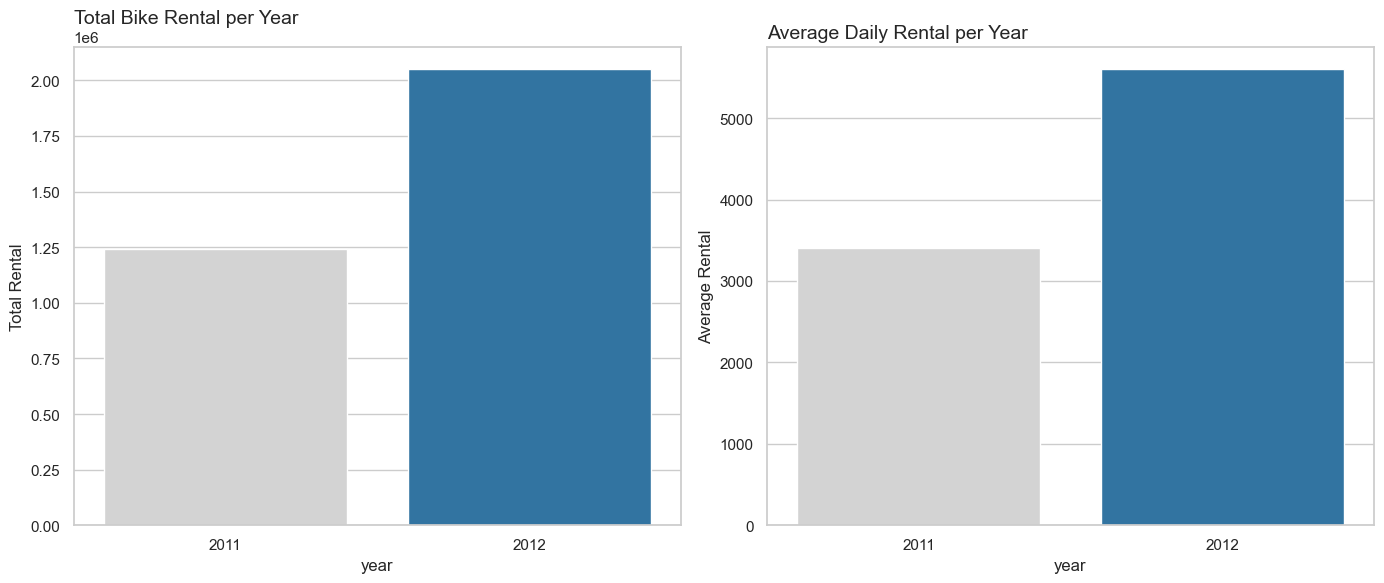

In [36]:
fig, ax = plt.subplots(1, 2, figsize=(14,6))

colors_yearly = ["#1f77b4" if (x == yearly_summary['total_rental'].max()) else "#D3D3D3" for x in yearly_summary['total_rental']]

sns.barplot(x=yearly_summary.index, y='total_rental', data=yearly_summary, palette=colors_yearly, ax=ax[0])
ax[0].set_title("Total Bike Rental per Year", loc='left', fontsize=14)
ax[0].set_ylabel("Total Rental")

sns.barplot(x=yearly_summary.index, y='average_rental', data=yearly_summary, palette=colors_yearly, ax=ax[1])
ax[1].set_title("Average Daily Rental per Year", loc='left', fontsize=14)
ax[1].set_ylabel("Average Rental")

plt.tight_layout()
plt.show()

**Insight:**
- Berdasarkan visualisasi tersebut, terlihat bahwa terjadi pertumbuhan yang sangat signifikan pada penyewaan sepeda dari tahun 2011 ke 2012. Total penyewaan meningkat dari sekitar 1,24 juta pada 2011 menjadi lebih dari 2,04 juta pada 2012, yang berarti terjadi kenaikan sekitar 60–65% secara tahunan. Kenaikan ini menunjukkan adanya peningkatan adopsi layanan bike-sharing dalam kurun waktu satu tahun, baik dari sisi jumlah pengguna maupun frekuensi penggunaan.
- Dari sisi rata-rata harian, tren yang sama juga terlihat jelas. Rata-rata penyewaan harian meningkat dari sekitar 3.400 unit per hari pada 2011 menjadi sekitar 5.600 unit per hari pada 2012. Artinya, bukan hanya akumulasi tahunan yang meningkat, tetapi intensitas penggunaan per hari juga naik secara konsisten. Hal ini mengindikasikan bahwa layanan tidak hanya bertambah populer, tetapi juga semakin menjadi bagian dari kebiasaan mobilitas harian masyarakat.
- Insight ini menunjukkan bahwa tahun 2012 merupakan fase ekspansi atau pertumbuhan kuat bagi sistem bike-sharing. Kemungkinan faktor pendorongnya bisa meliputi peningkatan jumlah stasiun sepeda, bertambahnya pengguna terdaftar, promosi yang efektif, atau meningkatnya kesadaran masyarakat terhadap transportasi ramah lingkungan. Tren pertumbuhan yang tajam ini juga menjadi sinyal positif bahwa model bisnis memiliki potensi keberlanjutan dan skalabilitas yang baik.

### Pertanyaan 2: Pada musim apa rata-rata jumlah penyewaan paling tinggi selama periode 2011–2012?

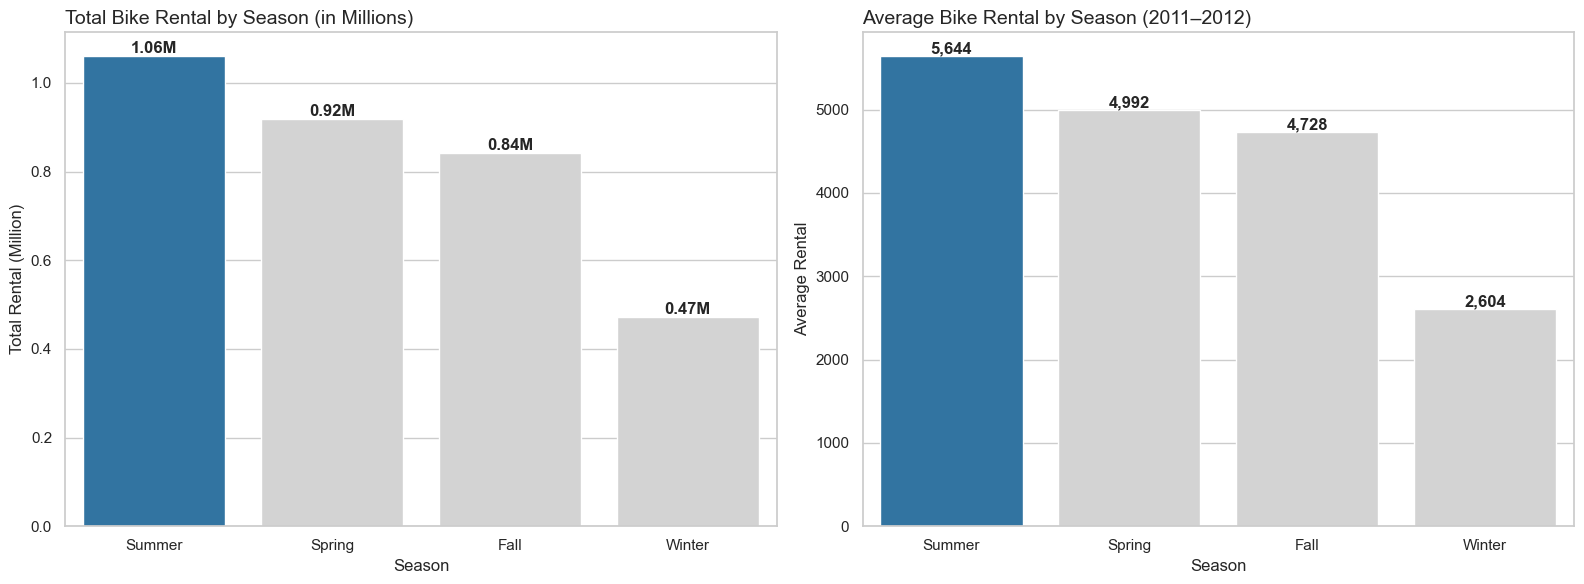

In [37]:
fig, ax = plt.subplots(1, 2, figsize=(16,6))

season_summary['total_million'] = season_summary['total_rental'] / 1_000_000

colors_season = ["#1f77b4" if (x == season_summary['total_million'].max()) else "#D3D3D3" for x in season_summary['total_million']]

sns.barplot(
    x=season_summary.index,
    y='total_million',
    data=season_summary,
    palette=colors_season,
    ax=ax[0]
)
ax[0].set_title("Total Bike Rental by Season (in Millions)", loc='left', fontsize=14)
ax[0].set_ylabel("Total Rental (Million)")
ax[0].set_xlabel("Season")

for i, v in enumerate(season_summary['total_million']):
    ax[0].text(i, v, f"{v:.2f}M", ha='center', va='bottom', fontweight='bold')

sns.barplot(
    x=season_summary.index,
    y='average_rental',
    data=season_summary,
    palette=colors_season,
    ax=ax[1]
)
ax[1].set_title("Average Bike Rental by Season (2011–2012)", loc='left', fontsize=14)
ax[1].set_ylabel("Average Rental")
ax[1].set_xlabel("Season")

for i, v in enumerate(season_summary['average_rental']):
    ax[1].text(i, v, f"{v:,.0f}", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

**Insight:**
- Berdasarkan ringkasan tersebut, terlihat bahwa musim Summer memiliki tingkat penyewaan sepeda tertinggi, baik dari sisi total maupun rata-rata harian. Selama periode 2011–2012, total penyewaan pada musim panas mencapai lebih dari 1,06 juta dengan rata-rata sekitar 5.644 penyewaan per hari. Hal ini menunjukkan bahwa kondisi cuaca yang hangat dan relatif stabil sangat mendukung aktivitas bersepeda, baik untuk kebutuhan transportasi maupun rekreasi.
- Di posisi kedua terdapat Spring dengan total sekitar 918 ribu dan rata-rata hampir 4.992 penyewaan per hari. Ini mengindikasikan bahwa ketika suhu mulai nyaman dan tidak terlalu ekstrem, minat masyarakat untuk menggunakan sepeda mulai meningkat secara signifikan. Sementara itu, Fall menunjukkan angka yang sedikit lebih rendah namun masih relatif tinggi, dengan rata-rata sekitar 4.728 penyewaan per hari. Artinya, selama cuaca masih cukup bersahabat, permintaan tetap stabil.
- Sebaliknya, Winter mencatat jumlah penyewaan paling rendah, dengan total sekitar 471 ribu dan rata-rata hanya 2.604 per hari—hampir setengah dari musim panas. Hal ini menunjukkan bahwa suhu dingin dan kemungkinan kondisi cuaca yang kurang mendukung (seperti hujan atau salju) menjadi faktor penghambat utama penggunaan sepeda.
- Secara bisnis, insight ini menegaskan bahwa musim dan kondisi cuaca merupakan faktor kunci dalam memengaruhi permintaan. Perusahaan dapat memanfaatkan musim dengan permintaan tinggi untuk memaksimalkan pendapatan, serta menyiapkan strategi khusus di musim dingin seperti promosi, diskon, atau optimalisasi operasional untuk menjaga efisiensi biaya.

### Pertanyaan 3: Pada jam berapa rata-rata penyewaan sepeda tertinggi terjadi dalam dua tahun terakhir?

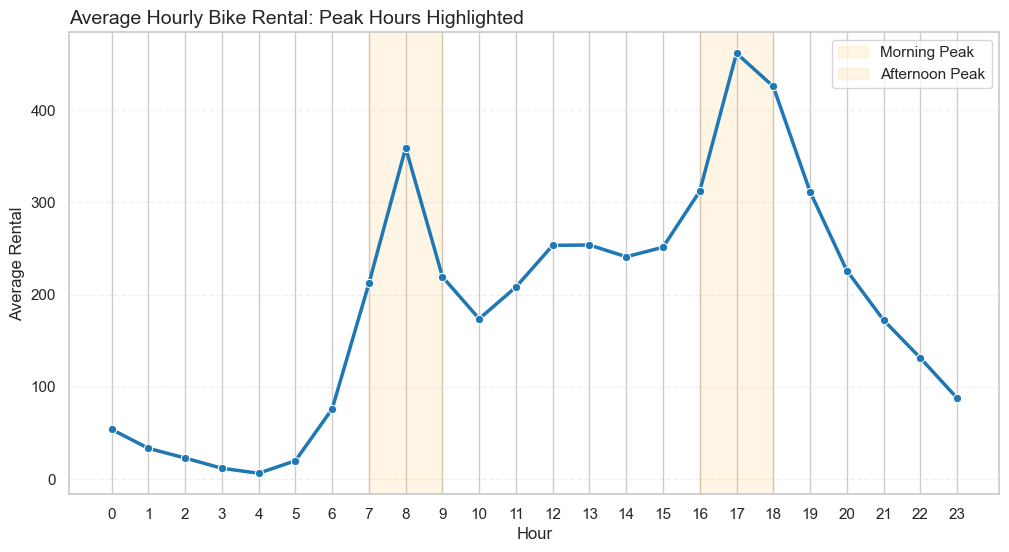

In [38]:
plt.figure(figsize=(12,6))

ax_hr = sns.lineplot(x=hourly_mean.index, y=hourly_mean.values, marker='o', color='#1f77b4', linewidth=2.5)

plt.axvspan(7, 9, color='orange', alpha=0.1, label='Morning Peak')
plt.axvspan(16, 18, color='orange', alpha=0.1, label='Afternoon Peak')

plt.title("Average Hourly Bike Rental: Peak Hours Highlighted", loc='left', fontsize=14)
plt.xlabel("Hour")
plt.ylabel("Average Rental")
plt.xticks(range(0,24))
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.legend()
plt.show()

**Insight:**
- Berdasarkan grafik rata-rata penyewaan sepeda per jam selama periode 2011–2012, terlihat pola yang sangat jelas membentuk dua puncak utama (bimodal pattern) dalam satu hari. Puncak pertama terjadi pada sekitar pukul 08.00 pagi, dengan rata-rata penyewaan yang meningkat tajam dibandingkan jam sebelumnya. Puncak kedua, sekaligus yang tertinggi, terjadi pada sekitar pukul 17.00–18.00, di mana rata-rata penyewaan mencapai nilai maksimum dalam sehari.
- Pola ini menunjukkan bahwa penggunaan sepeda sangat dipengaruhi oleh jam aktivitas kerja (commuting hours). Lonjakan pada pukul 08.00 mengindikasikan penggunaan sepeda untuk berangkat kerja atau sekolah, sedangkan lonjakan tertinggi pada pukul 17.00–18.00 mencerminkan aktivitas pulang kerja. Setelah pukul 19.00, jumlah penyewaan mulai menurun secara konsisten hingga malam hari.
- Sebaliknya, periode dini hari (00.00–05.00) menunjukkan tingkat penyewaan yang sangat rendah, yang mencerminkan minimnya aktivitas mobilitas pada jam tersebut.
- Secara bisnis, insight ini sangat penting karena menunjukkan bahwa sistem bike-sharing berfungsi sebagai transportasi pendukung mobilitas harian, bukan sekadar alat rekreasi. Hal ini dapat menjadi dasar dalam:
1. Pengaturan distribusi sepeda pada jam sibuk,
2. Penjadwalan operasional dan maintenance,
3. Strategi penambahan kapasitas di jam puncak sore hari,
4. Optimalisasi ketersediaan sepeda di area perkantoran saat jam commute.

Kesimpulannya, jam dengan rata-rata penyewaan tertinggi terjadi pada pukul 17.00–18.00, diikuti oleh lonjakan kedua pada pukul 08.00 pagi, yang secara kuat menunjukkan pola perilaku pengguna.

### Pertanyaan 4: Bagaimana perbedaan pola penyewaan per jam antara hari kerja dan akhir pekan?

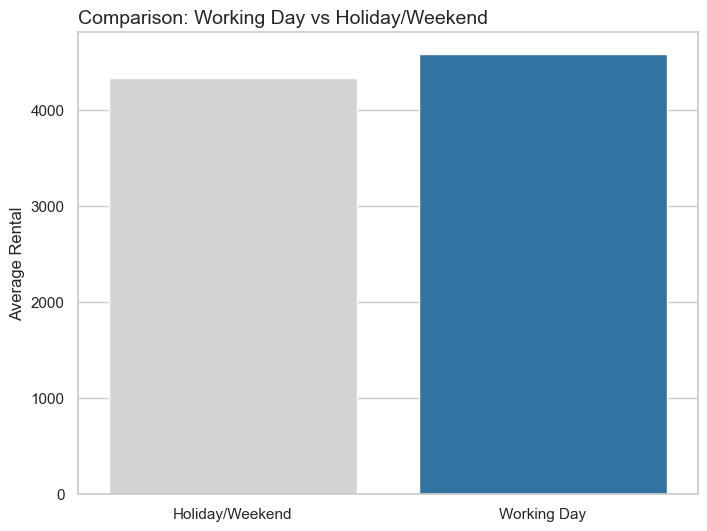

In [39]:
plt.figure(figsize=(8,6))
colors_daytype = ["#1f77b4" if (x == daytype_mean.values.max()) else "#D3D3D3" for x in daytype_mean.values]

sns.barplot(x=daytype_mean.index, y=daytype_mean.values, palette=colors_daytype)

plt.title("Comparison: Working Day vs Holiday/Weekend", loc='left', fontsize=14)
plt.ylabel("Average Rental")
plt.xlabel(None)
plt.show()

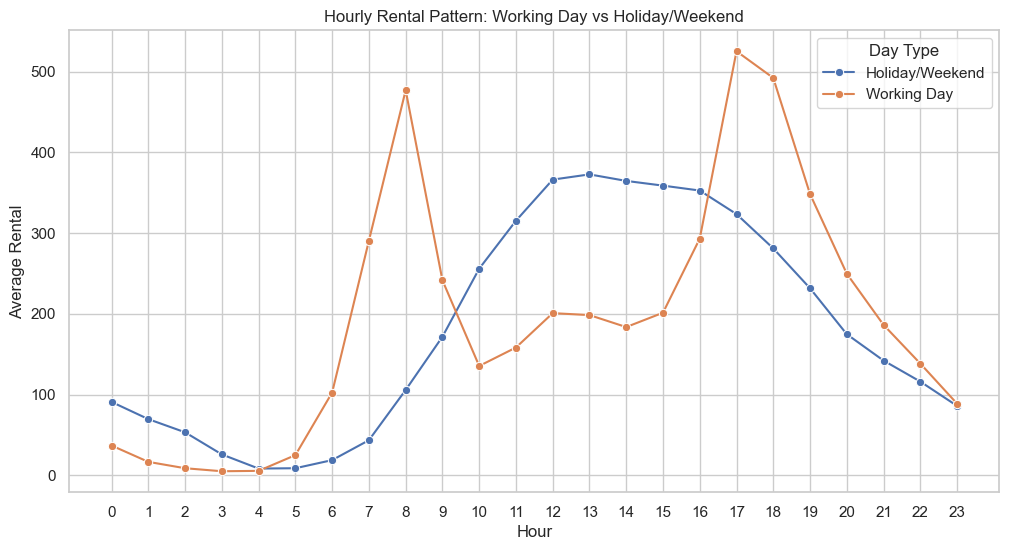

In [40]:
plt.figure(figsize=(12,6))
sns.lineplot(data=hour_daytype, x='hr', y='cnt', hue='day_type', marker='o')

plt.title("Hourly Rental Pattern: Working Day vs Holiday/Weekend")
plt.xlabel("Hour")
plt.ylabel("Average Rental")
plt.xticks(range(0,24))
plt.legend(title="Day Type")
plt.show()

**Insight:**
- Berdasarkan visualisasi perbandingan antara hari kerja (Working Day) dan hari libur/akhir pekan (Holiday/Weekend), terdapat perbedaan pola penyewaan yang sangat jelas dan mencerminkan perbedaan tujuan penggunaan sepeda.
- Dari grafik rata-rata keseluruhan, terlihat bahwa hari kerja memiliki rata-rata penyewaan yang sedikit lebih tinggi dibandingkan akhir pekan. Hal ini menunjukkan bahwa secara umum sepeda lebih intens digunakan pada hari kerja, kemungkinan besar untuk kebutuhan transportasi rutin.
Pada hari kerja, terlihat pola “dua puncak” yang sangat tajam:
1. Puncak pertama terjadi sekitar pukul 08.00 pagi.
2. Puncak tertinggi terjadi sekitar pukul 17.00–18.00 sore.
- Pola ini sangat identik dengan jam berangkat dan pulang kerja (commuting pattern). Artinya, sepeda banyak digunakan sebagai alat transportasi harian menuju dan dari tempat kerja atau sekolah. Sebaliknya, pada akhir pekan atau hari libur, pola penyewaan lebih:
1. Stabil dan merata sepanjang siang hari.
2. Meningkat secara bertahap mulai pagi.
3. Mencapai puncak sekitar pukul 12.00–15.00.
4. Tidak menunjukkan lonjakan tajam di pagi atau sore hari.
- Ini mengindikasikan bahwa pada akhir pekan sepeda lebih banyak digunakan untuk aktivitas rekreasi, olahraga, atau kegiatan santai, bukan untuk mobilitas kerja. Secara bisnis, insight ini sangat strategis:
1. Pada hari kerja, perusahaan perlu memastikan ketersediaan sepeda optimal di jam sibuk pagi dan sore.
2. Pada akhir pekan, distribusi sepeda bisa difokuskan di area rekreasi atau pusat kota.
3. Strategi promosi juga bisa dibedakan — misalnya promo commuting pass untuk weekday dan promo leisure package untuk weekend.
- Kesimpulannya, sistem bike-sharing berfungsi sebagai transportasi komuter pada hari kerja dan alat rekreasi pada akhir pekan, yang menunjukkan fleksibilitas model bisnis dan segmentasi perilaku pengguna yang jelas.

### Pertanyaan 5: Seberapa besar hubungan antara suhu, kelembapan, dan kecepatan angin terhadap jumlah penyewaan harian selama 2011–2012?

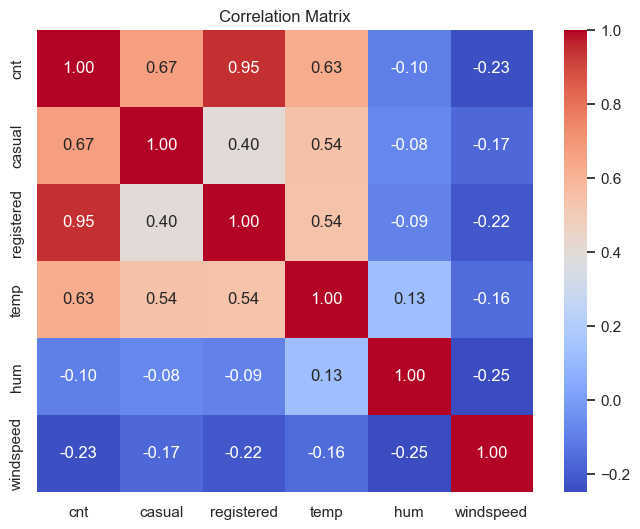

In [41]:
plt.figure(figsize=(8,6))
sns.heatmap(selected_corr, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Matrix")
plt.show()

**Insight:**
- Berdasarkan hasil matriks korelasi, dapat terlihat bahwa suhu memiliki pengaruh paling kuat terhadap jumlah penyewaan sepeda, dengan korelasi sebesar 0.63. Artinya, ketika suhu meningkat, aktivitas penyewaan sepeda juga cenderung meningkat karena kondisi cuaca yang lebih hangat dan nyaman mendorong orang untuk bersepeda. Di sisi lain, kelembapan memiliki hubungan negatif yang sangat lemah terhadap jumlah penyewaan (-0.10), sehingga meskipun udara yang terlalu lembap sedikit mengurangi kenyamanan, dampaknya terhadap keputusan pengguna untuk menyewa sepeda relatif kecil. Sementara itu, kecepatan angin menunjukkan korelasi negatif yang lebih jelas (-0.23), menandakan bahwa angin yang lebih kencang dapat mengurangi minat penyewaan karena kondisi bersepeda menjadi lebih berat dan berpotensi berbahaya. Selain faktor cuaca, jumlah penyewaan sangat dipengaruhi oleh pengguna terdaftar (registered) yang memiliki korelasi sangat tinggi terhadap total penyewaan (0.95), menunjukkan bahwa sebagian besar aktivitas penyewaan berasal dari pengguna rutin, sedangkan pengguna kasual memiliki korelasi sedang (0.67).
- Secara keseluruhan, kondisi suhu menjadi faktor cuaca yang paling meningkatkan penyewaan, sementara angin kencang menjadi faktor yang paling mengurangi, dan pengguna tetap (registered) memainkan peran terbesar dalam volume penyewaan harian.

### Pertanyaan 6: Bagaimana kontribusi pengguna kasual dan terdaftar terhadap total penyewaan selama 2 tahun terakhir?

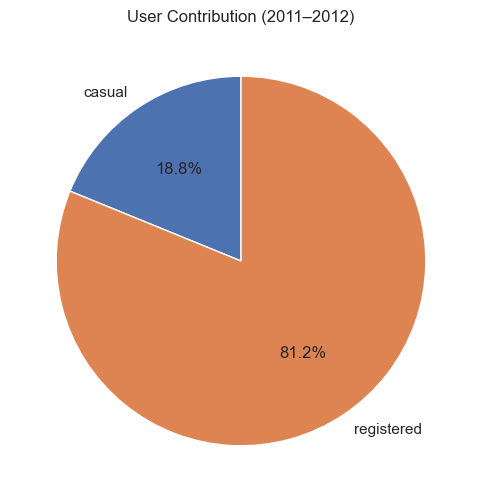

In [42]:
plt.figure(figsize=(6,6))
plt.pie(user_total, labels=user_total.index, autopct='%1.1f%%', startangle=90)
plt.title("User Contribution (2011–2012)")
plt.show()

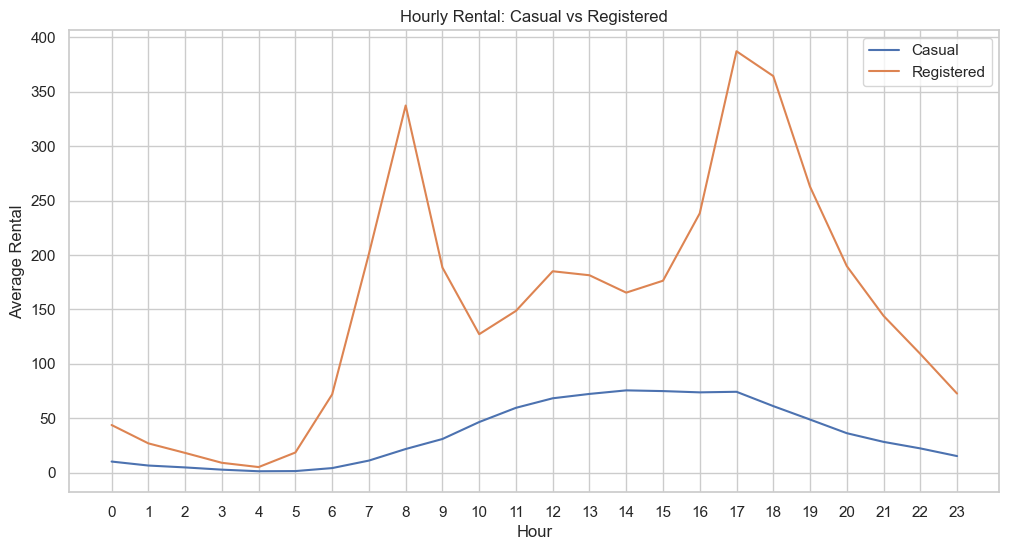

In [43]:
plt.figure(figsize=(12,6))
sns.lineplot(data=hour_user, x='hr', y='casual', label='Casual')
sns.lineplot(data=hour_user, x='hr', y='registered', label='Registered')

plt.title("Hourly Rental: Casual vs Registered")
plt.xlabel("Hour")
plt.ylabel("Average Rental")
plt.xticks(range(0,24))
plt.legend()
plt.show()

**Insight:**
- Berdasarkan diagram pie, terlihat bahwa pengguna terdaftar (registered) mendominasi penyewaan sepeda, dengan kontribusi sekitar 81.2%, sedangkan pengguna casual hanya memberikan kontribusi 18.8%. Ini menunjukkan bahwa sebagian besar aktivitas penyewaan berasal dari pengguna yang sudah memiliki akun tetap, yang kemungkinan menggunakan sepeda untuk kebutuhan rutin seperti berangkat kerja, sekolah, atau aktivitas harian lainnya. Sementara itu, pengguna casual cenderung muncul untuk aktivitas tidak rutin, seperti rekreasi, akhir pekan, atau saat cuaca mendukung.
- Jika dilihat dari grafik penyewaan per jam, pola ini semakin terlihat jelas. Pengguna registered memiliki dua puncak penyewaan besar, yaitu pada jam 8 pagi dan jam 17–18 sore. Pola ini sangat mirip dengan pola mobilitas pekerja atau pelajar yang berangkat dan pulang kerja/sekolah. Artinya, sepeda digunakan sebagai alat transportasi komuter oleh pengguna registered.
- Sebaliknya, pengguna casual menunjukkan pola yang lebih datar, tanpa puncak besar di jam kerja. Mereka lebih banyak menyewa pada siang hari hingga sore, yang menunjukkan bahwa penyewaan mereka lebih berorientasi pada rekreasi dibanding mobilitas rutin. Intensitas penyewaan casual jauh lebih rendah dibanding registered di setiap jam. Insight utama yang didapat adalah sebagai berikut.
1. Registered users adalah penyumbang terbesar penyewaan (81.2%), sehingga mereka merupakan target utama untuk optimalisasi layanan.
2. Casual users hanya 18.8%, namun berpotensi meningkat pada akhir pekan atau event tertentu.
3. Pola jam penyewaan registered menegaskan penggunaan sepeda sebagai komuter, dengan dua puncak waktu (morning & evening rush hour).
4. Pengguna casual lebih aktif pada siang hari, mencerminkan pola penggunaan rekreasional.
5. Strategi bisnis sebaiknya fokus pada peningkatan layanan komuter, namun tetap bisa mengembangkan paket rekreasi untuk menarik pengguna casual.

## Analisis Lanjutan (Opsional)

In [44]:
def kelompok_peminjaman(jumlah):
    if jumlah < 3000:
        return "Permintaan Rendah"
    elif jumlah < 4500:
        return "Permintaan Sedang"
    else:
        return "Permintaan Tinggi"

day_df['kategori_peminjaman'] = day_df['cnt'].apply(kelompok_peminjaman)

day_df['kategori_peminjaman'].value_counts()

kategori_peminjaman
Permintaan Tinggi    372
Permintaan Sedang    187
Permintaan Rendah    172
Name: count, dtype: int64

Pada tahap ini dilakukan proses clustering manual menggunakan metode rule-based grouping untuk mengelompokkan tingkat peminjaman sepeda berdasarkan jumlah total peminjaman (cnt). Fungsi kelompok_peminjaman() digunakan untuk mengklasifikasikan data ke dalam tiga kategori yaitu Permintaan Rendah untuk jumlah peminjaman kurang dari 3000, Permintaan Sedang untuk jumlah antara 3000 hingga 4499, dan Permintaan Tinggi untuk jumlah peminjaman 4500 atau lebih. Kategori tersebut kemudian disimpan dalam kolom baru bernama kategori_peminjaman. Setelah proses pengelompokan selesai, dilakukan pengecekan jumlah data pada setiap kategori menggunakan value_counts() untuk mengetahui distribusi jumlah hari dalam setiap kelompok permintaan.

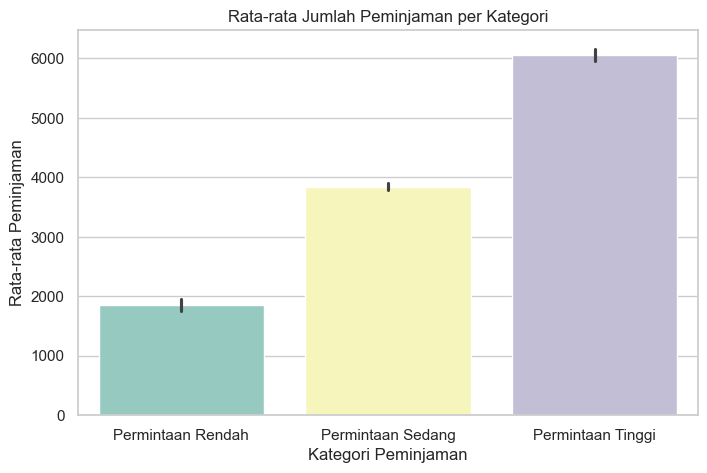

In [45]:
plt.figure(figsize=(8,5))
sns.barplot(data=day_df, x='kategori_peminjaman', y='cnt', palette='Set3', estimator=np.mean)

plt.title("Rata-rata Jumlah Peminjaman per Kategori")
plt.xlabel("Kategori Peminjaman")
plt.ylabel("Rata-rata Peminjaman")
plt.show()

**Insight:**
- Visualisasi ini menggunakan barplot untuk menampilkan rata-rata jumlah peminjaman sepeda (cnt) pada setiap kategori permintaan yang telah dibuat sebelumnya. Grafik ini bertujuan untuk memperlihatkan perbedaan tingkat peminjaman antara kategori Permintaan Rendah, Permintaan Sedang, dan Permintaan Tinggi secara lebih jelas.
- Dari grafik dapat terlihat bahwa setiap kategori memiliki perbedaan rata-rata jumlah peminjaman yang signifikan, di mana kategori Permintaan Tinggi menunjukkan jumlah peminjaman yang paling besar, sedangkan kategori Permintaan Rendah memiliki rata-rata peminjaman paling sedikit. Visualisasi ini membantu memperkuat hasil pengelompokan yang telah dilakukan sebelumnya.

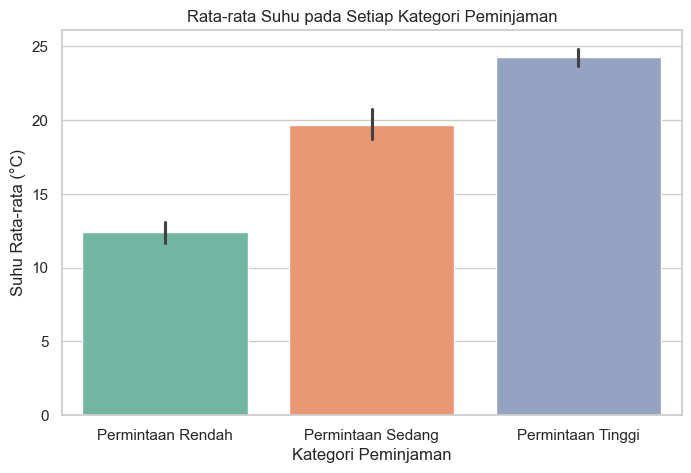

In [46]:
plt.figure(figsize=(8,5))
sns.barplot(data=day_df, x='kategori_peminjaman', y='temp_celsius', palette='Set2', estimator=np.mean)

plt.title("Rata-rata Suhu pada Setiap Kategori Peminjaman")
plt.xlabel("Kategori Peminjaman")
plt.ylabel("Suhu Rata-rata (°C)")
plt.show()

**Insight:**
- Pada visualisasi ini ditampilkan hubungan antara suhu rata-rata (temp_celsius) dengan kategori peminjaman sepeda. Grafik barplot digunakan untuk melihat apakah terdapat kecenderungan tertentu antara kondisi suhu dan jumlah peminjaman sepeda.
- Hasil visualisasi menunjukkan bahwa kategori Permintaan Tinggi cenderung terjadi pada suhu yang lebih tinggi dibandingkan kategori lainnya. Sebaliknya, kategori Permintaan Rendah cenderung terjadi pada suhu yang lebih rendah. Hal ini menunjukkan bahwa kondisi suhu kemungkinan memiliki pengaruh terhadap tingkat penggunaan sepeda oleh pengguna.

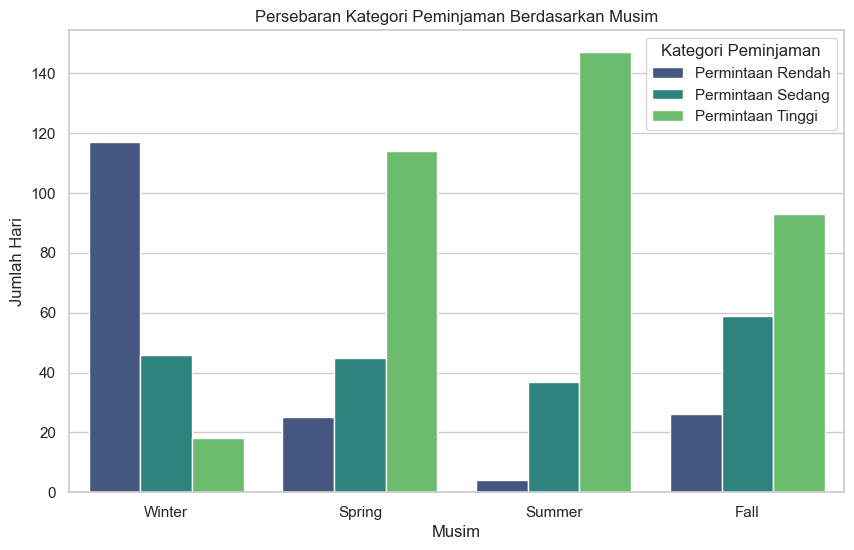

In [47]:
plt.figure(figsize=(10,6))
sns.countplot(data=day_df, x='season', hue='kategori_peminjaman', palette='viridis')

plt.title("Persebaran Kategori Peminjaman Berdasarkan Musim")
plt.xlabel("Musim")
plt.ylabel("Jumlah Hari")
plt.legend(title="Kategori Peminjaman")
plt.show()

**Insight:**
- Visualisasi ini menampilkan distribusi kategori peminjaman sepeda berdasarkan musim menggunakan countplot dengan pembeda warna (hue) untuk setiap kategori permintaan. Grafik ini bertujuan untuk melihat bagaimana pola peminjaman sepeda tersebar di berbagai musim seperti Winter, Spring, Summer, dan Fall.
- Dari grafik terlihat bahwa kategori Permintaan Tinggi lebih banyak terjadi pada musim Summer dan Fall, sedangkan Permintaan Rendah lebih sering terjadi pada musim Winter. Hal ini menunjukkan bahwa faktor musim memiliki pengaruh terhadap tingkat penggunaan sepeda, di mana kondisi cuaca yang lebih hangat cenderung meningkatkan aktivitas peminjaman sepeda.

## Conclusion

### Pertanyaan 1: Bagaimana pertumbuhan rata-rata dan total penyewaan sepeda antara tahun 2011 dan 2012?

**Kesimpulan:** Terjadi pertumbuhan signifikan pada penyewaan sepeda, baik dari total maupun rata-rata harian, antara tahun 2011 dan 2012. Total penyewaan meningkat sekitar 64.88% (dari 1,24 juta menjadi 2,04 juta), dan rata-rata harian naik dari 3.406 menjadi 5.600 unit. Ini menunjukkan peningkatan adopsi layanan dan intensitas penggunaan, menandakan fase ekspansi yang kuat dan potensi skalabilitas.

### Pertanyaan 2: Pada musim apa rata-rata jumlah penyewaan paling tinggi selama periode 2011–2012?

**Kesimpulan:** Musim Summer memiliki rata-rata penyewaan tertinggi (5.644 unit/hari), diikuti oleh Spring (4.992 unit/hari), dan Fall (4.728 unit/hari). Musim Winter mencatat angka terendah (2.604 unit/hari). Ini menegaskan bahwa cuaca hangat mendukung aktivitas bersepeda, sementara suhu dingin menjadi penghambat utama. Bisnis harus memanfaatkan musim ramai dan menyusun strategi khusus di musim dingin.

### Pertanyaan 3: Pada jam berapa rata-rata penyewaan sepeda tertinggi terjadi dalam dua tahun terakhir?

**Kesimpulan:** Rata-rata penyewaan sepeda menunjukkan pola bimodal dengan dua puncak utama: pukul 08.00 pagi dan puncak tertinggi pada pukul 17.00–18.00 sore. Pola ini sangat mencerminkan jam sibuk (commuting hours), menunjukkan bahwa sepeda banyak digunakan untuk mobilitas harian (berangkat dan pulang kerja/sekolah). Periode dini hari (00.00–05.00) memiliki tingkat penyewaan terendah.

### Pertanyaan 4: Bagaimana perbedaan pola penyewaan per jam antara hari kerja dan akhir pekan?

**Kesimpulan:** Terdapat perbedaan pola penyewaan yang jelas: pada hari kerja, penyewaan memiliki dua puncak tajam (pukul 08.00 dan 17.00–18.00), sesuai dengan pola komuter. Sementara itu, pada akhir pekan/hari libur, pola penyewaan lebih stabil dan merata sepanjang siang hingga sore (puncak sekitar pukul 12.00–15.00), menunjukkan penggunaan untuk rekreasi atau kegiatan santai. Ini mengindikasikan bahwa layanan berfungsi sebagai transportasi komuter di hari kerja dan rekreasi di akhir pekan.

### Pertanyaan 5: Seberapa besar hubungan antara suhu, kelembapan, dan kecepatan angin terhadap jumlah penyewaan harian selama 2011–2012?

**Kesimpulan:** Suhu (temp) memiliki korelasi positif yang kuat dengan jumlah penyewaan (0.63), artinya cuaca yang lebih hangat meningkatkan minat bersepeda. Kelembapan (hum) memiliki korelasi negatif yang sangat lemah (-0.10). Kecepatan angin (windspeed) memiliki korelasi negatif yang lebih jelas (-0.23), menunjukkan bahwa angin kencang dapat mengurangi aktivitas penyewaan. Secara keseluruhan, suhu adalah faktor cuaca paling berpengaruh positif, sedangkan angin kencang berpengaruh negatif.

### Pertanyaan 6: Berapa perbedaan rata-rata jumlah penyewaan antara hari kerja dan hari libur?

**Kesimpulan:** Rata-rata penyewaan pada Hari Kerja (Working Day) sedikit lebih tinggi (4.585 unit) dibandingkan Hari Libur/Akhir Pekan (Holiday/Weekend) (4.330 unit). Meskipun perbedaannya tidak terlalu besar, ini memperkuat bahwa layanan bike-sharing cenderung lebih sering dimanfaatkan untuk aktivitas rutin pada hari kerja dibandingkan untuk rekreasi pada akhir pekan/libur.

### Pertanyaan 7: Bagaimana kontribusi pengguna kasual dan terdaftar terhadap total penyewaan selama 2 tahun terakhir?

**Kesimpulan:** Pengguna terdaftar (registered) mendominasi total penyewaan secara signifikan, menyumbang sekitar 81.2% (2.672.662 unit), sementara pengguna kasual (casual) hanya 18.8% (620.017 unit). Pola jam penyewaan juga berbeda: registered users memiliki puncak di jam sibuk pagi (08.00) dan sore (17.00–18.00) yang khas komuter, sedangkan casual users memiliki pola yang lebih merata di siang hari tanpa puncak tajam. Ini menunjukkan bahwa strategi bisnis harus fokus pada pengguna terdaftar sebagai target utama sambil tetap menarik pengguna kasual untuk tujuan rekreasi.